C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\rsp\plotting\Rsp_Kit.py:415: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


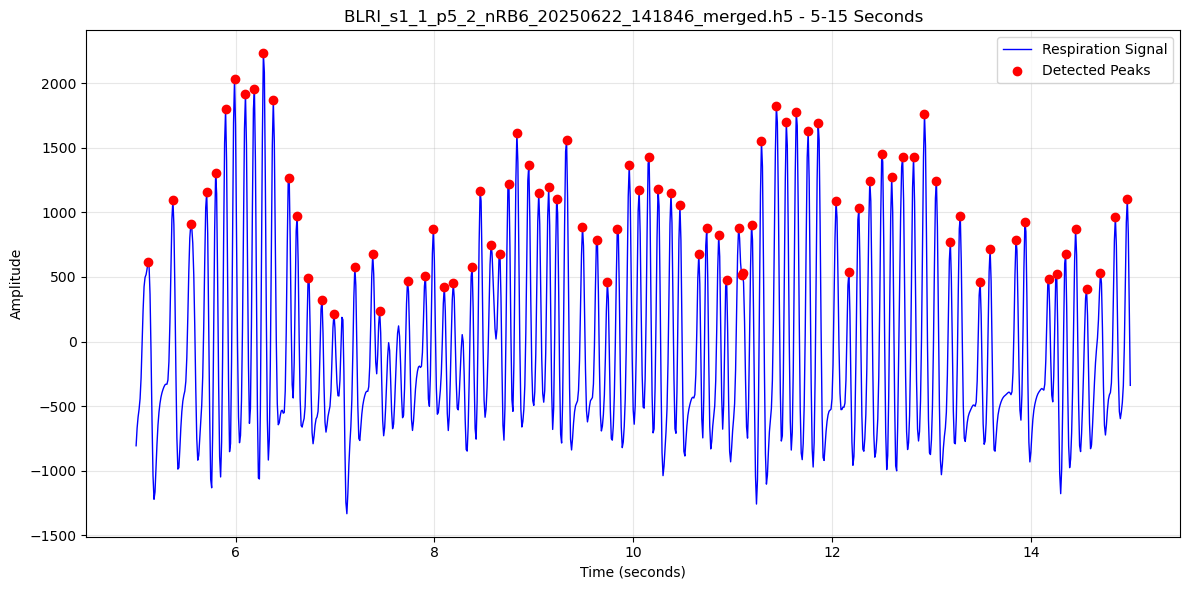

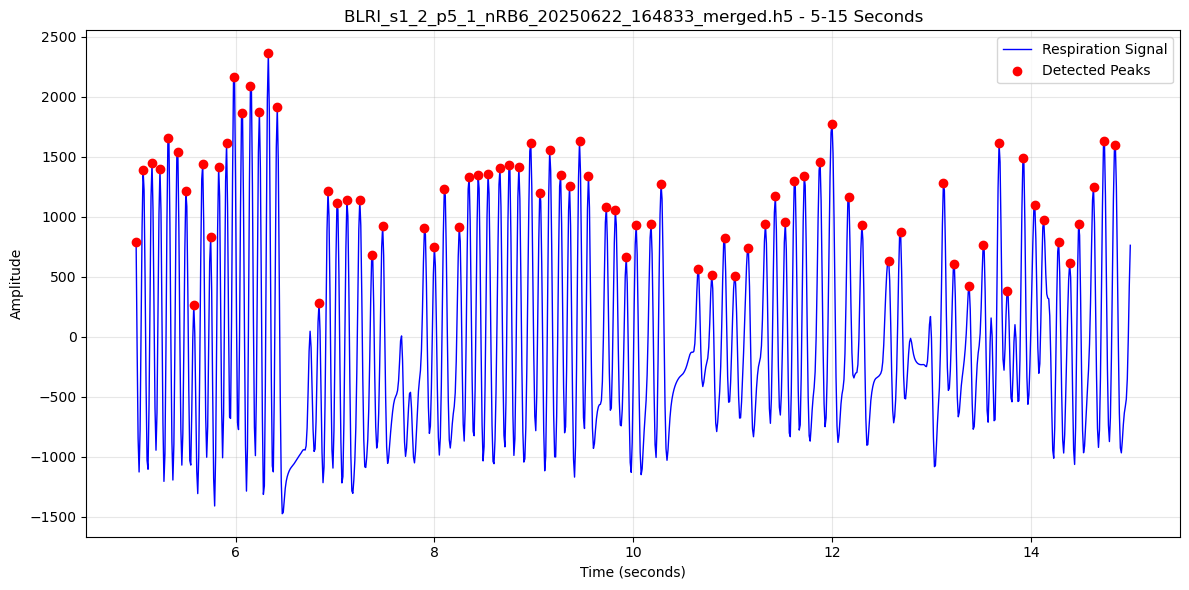

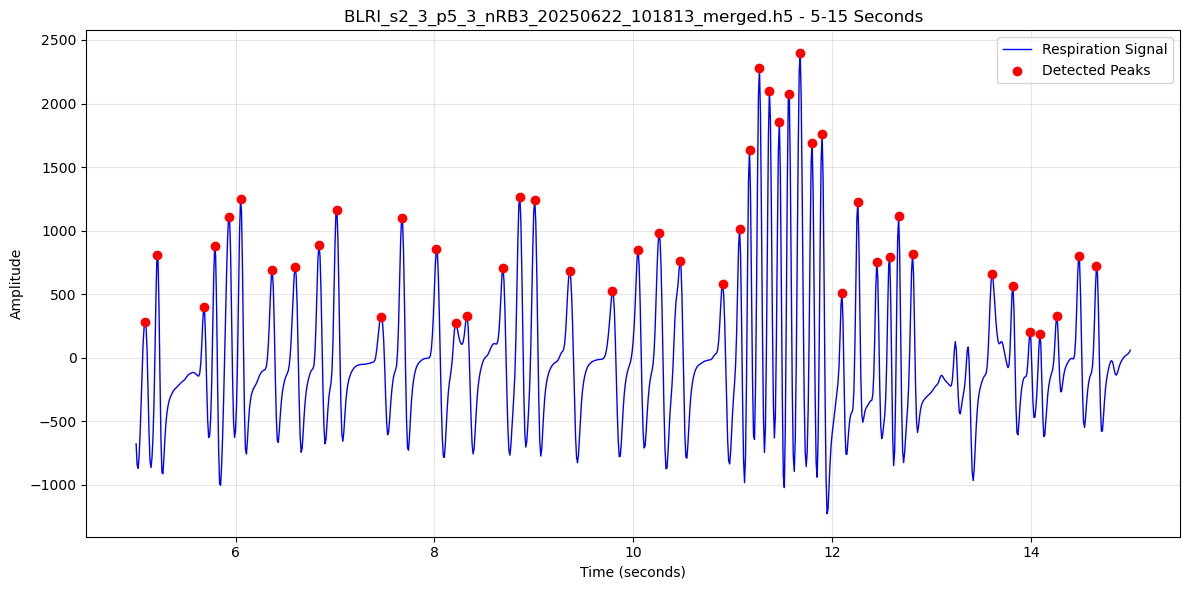

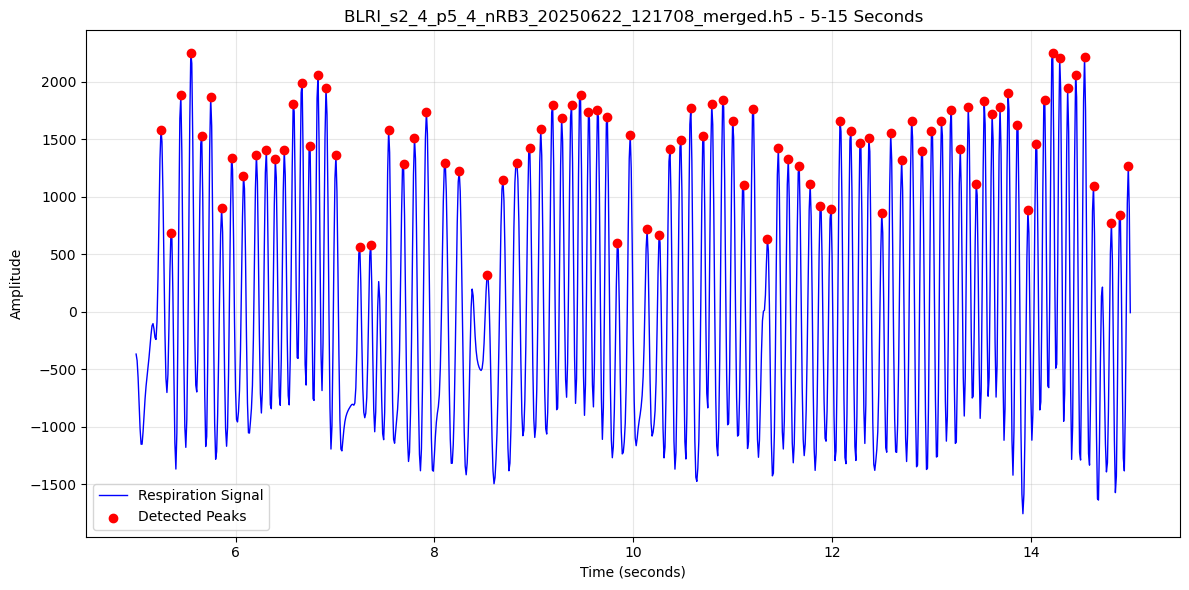

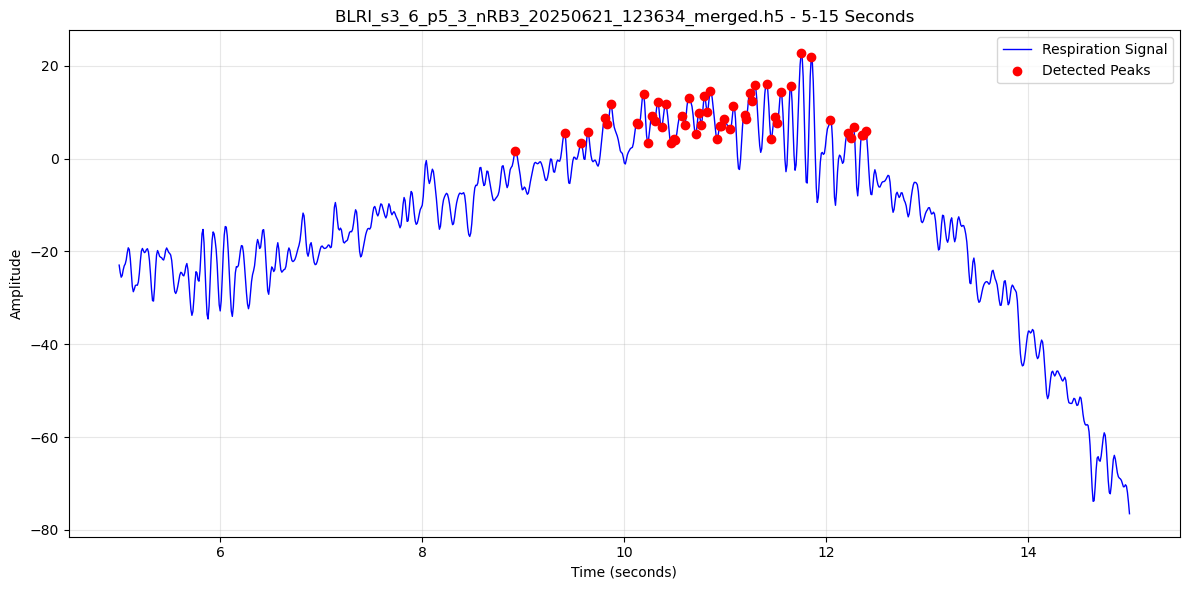

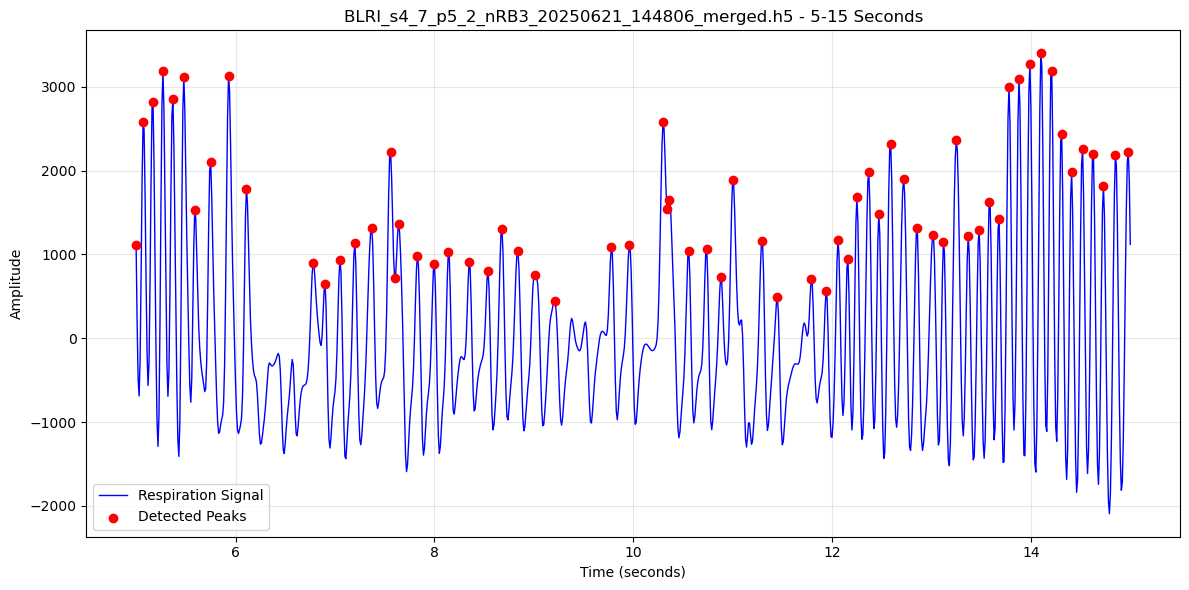

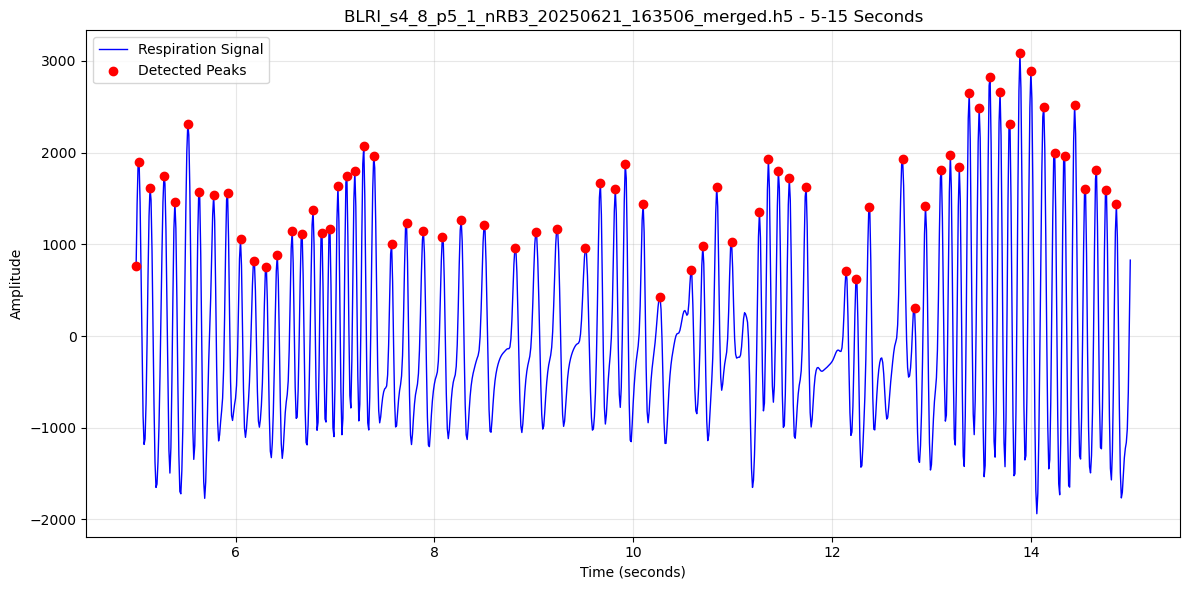

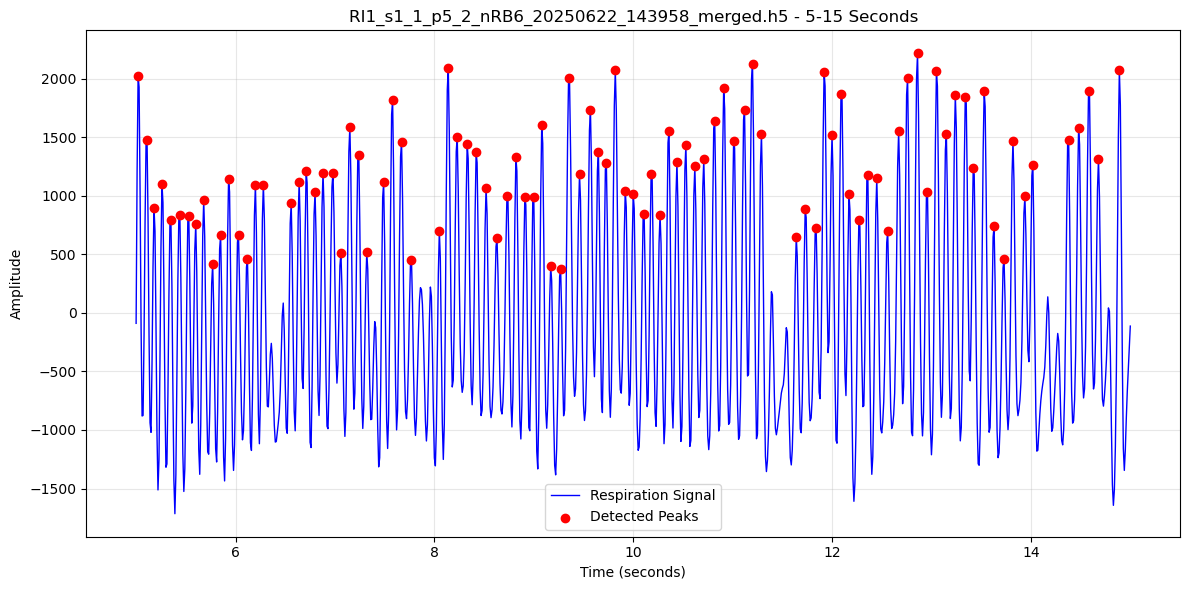

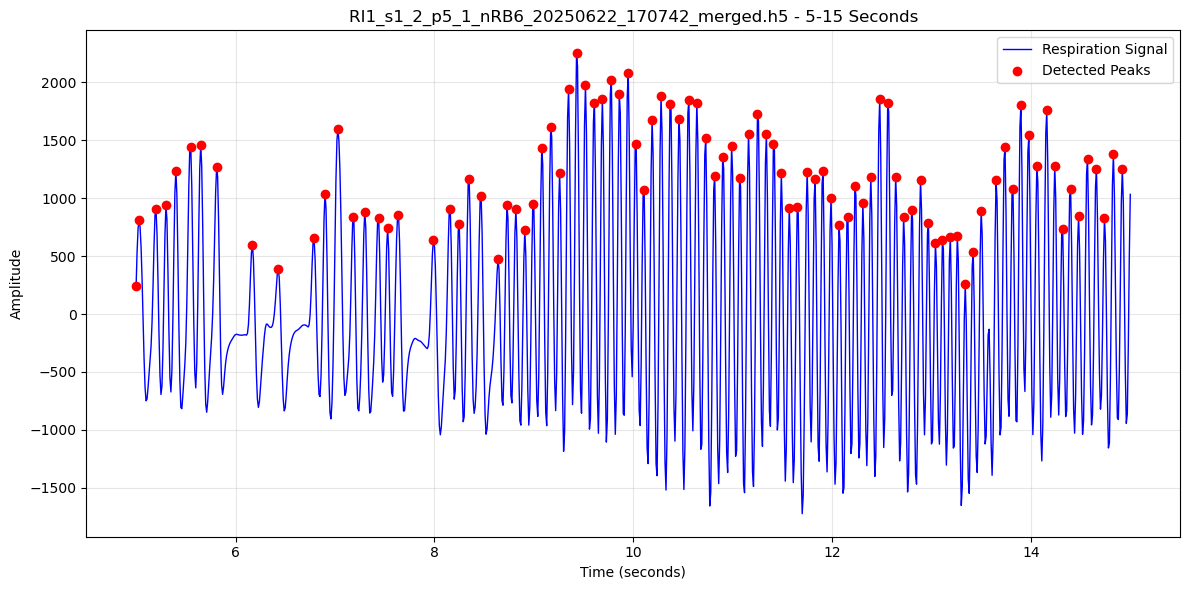

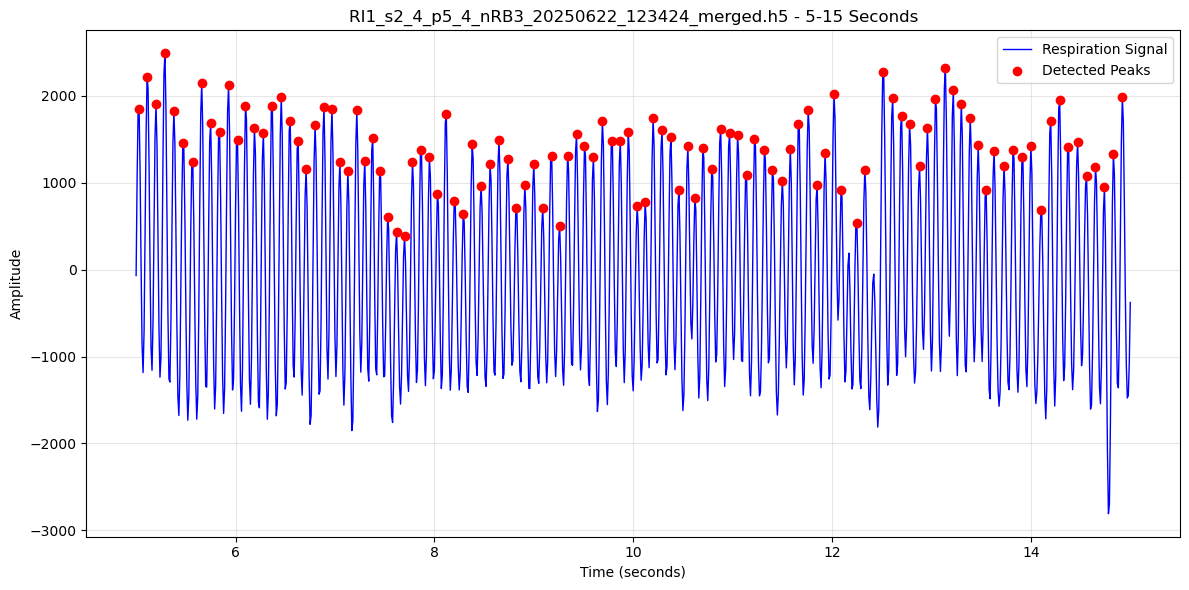

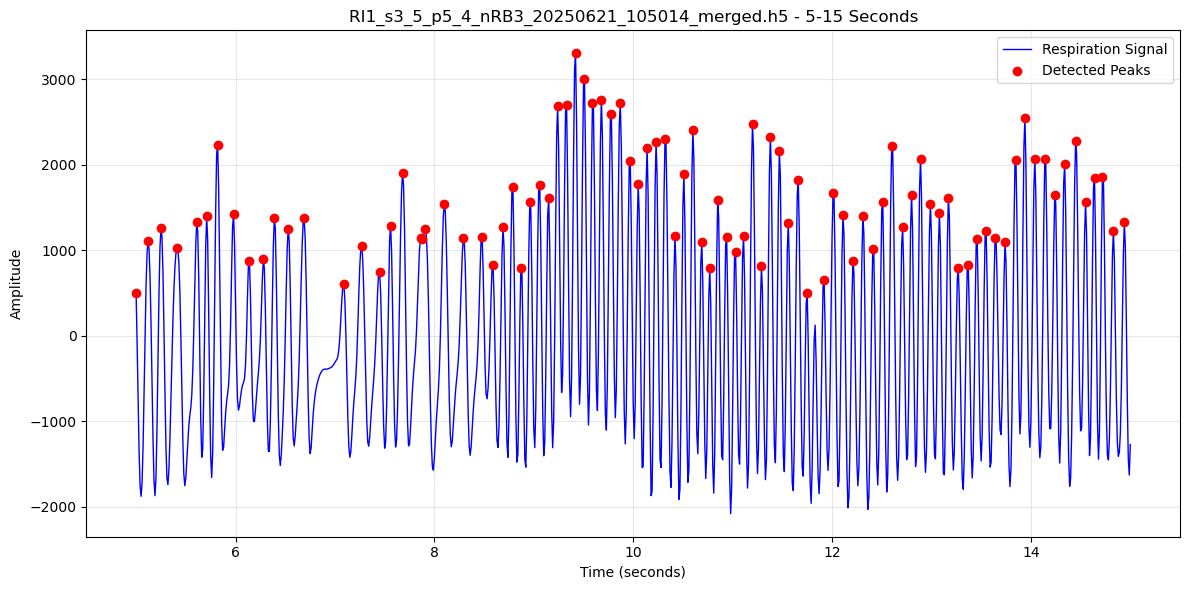

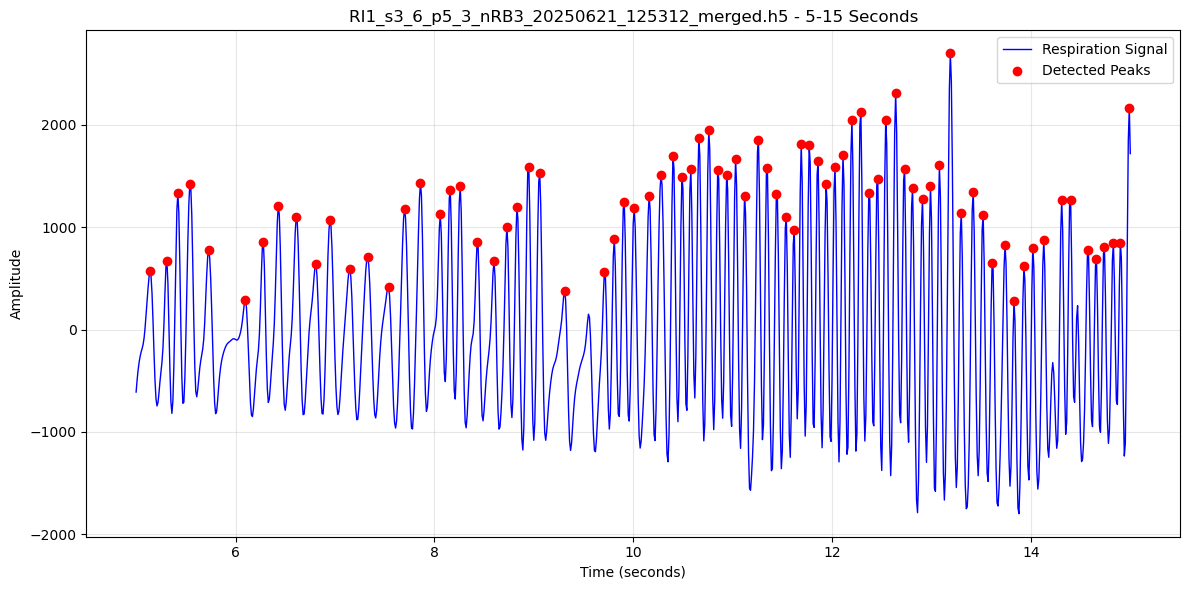

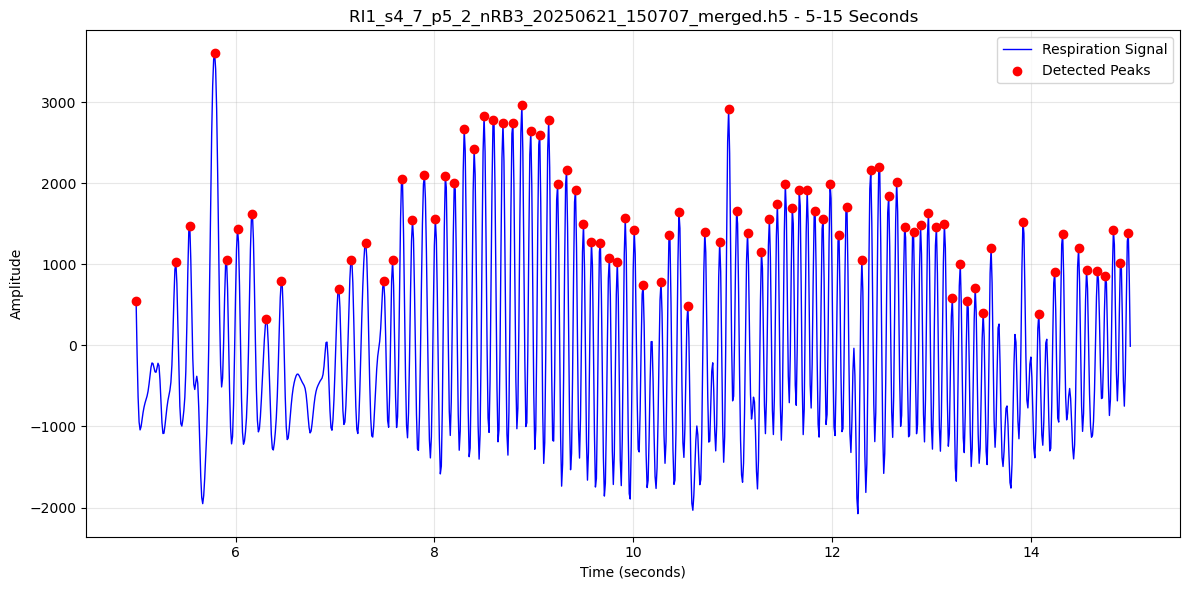

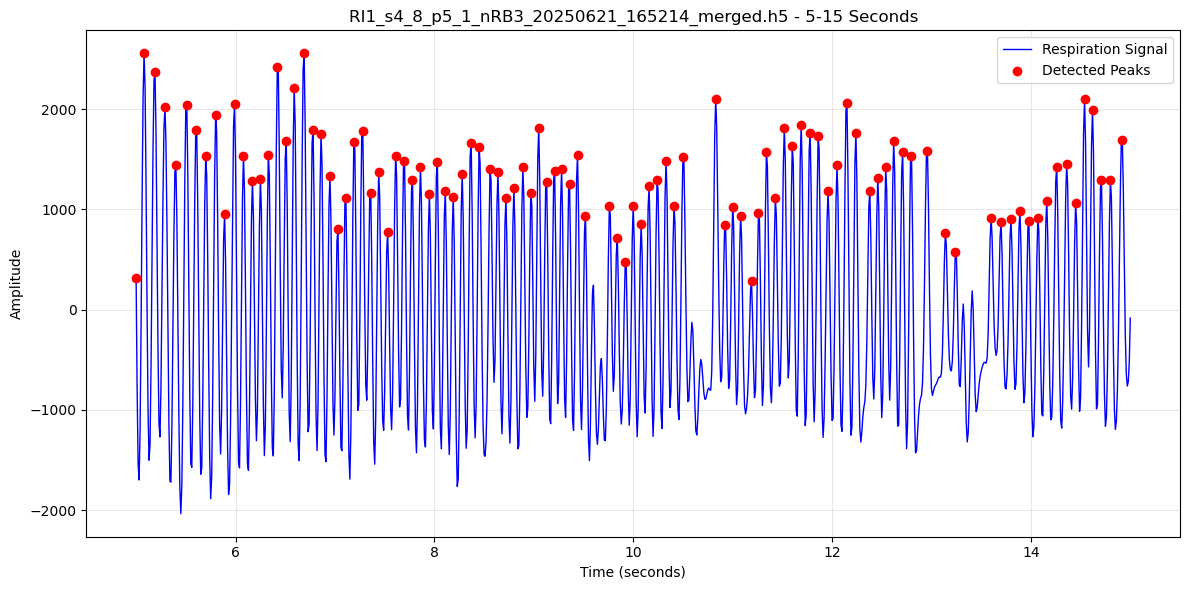

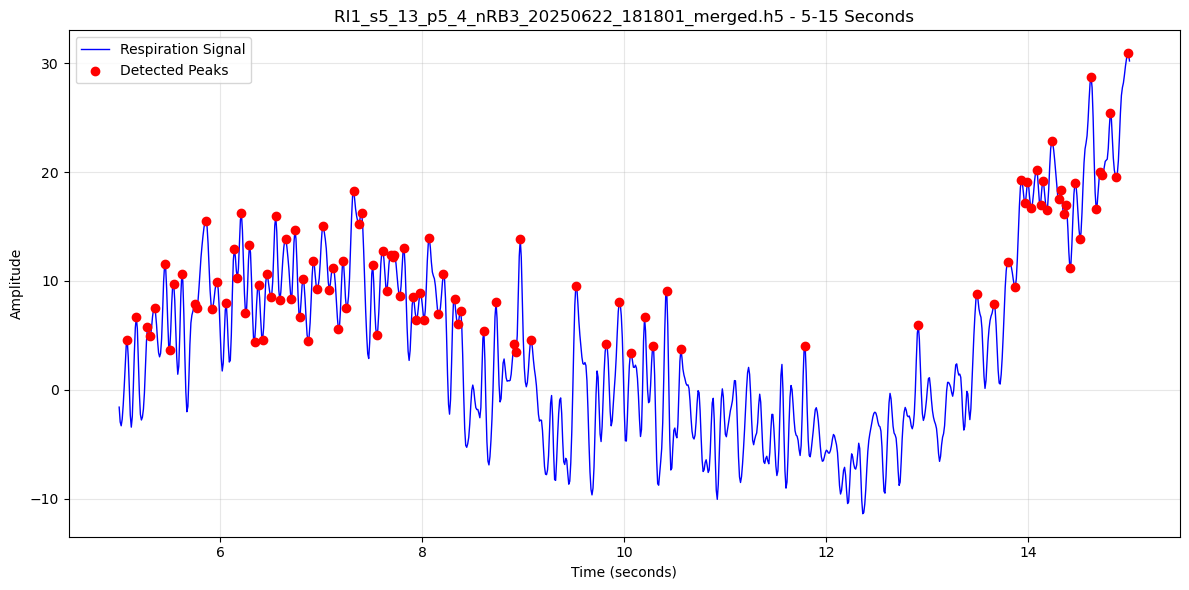

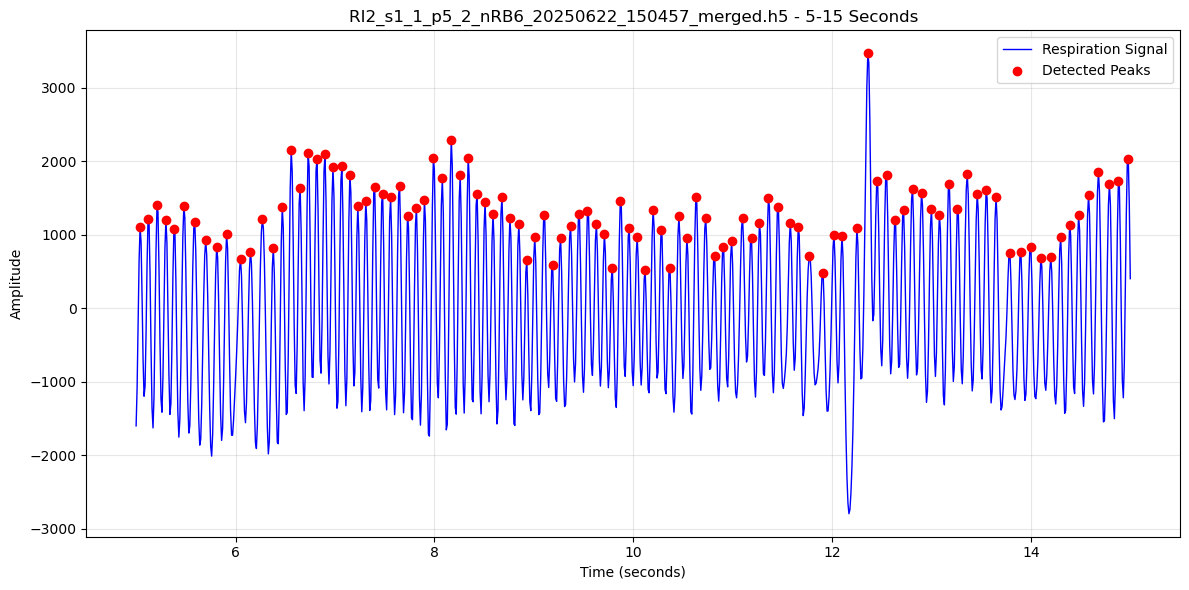

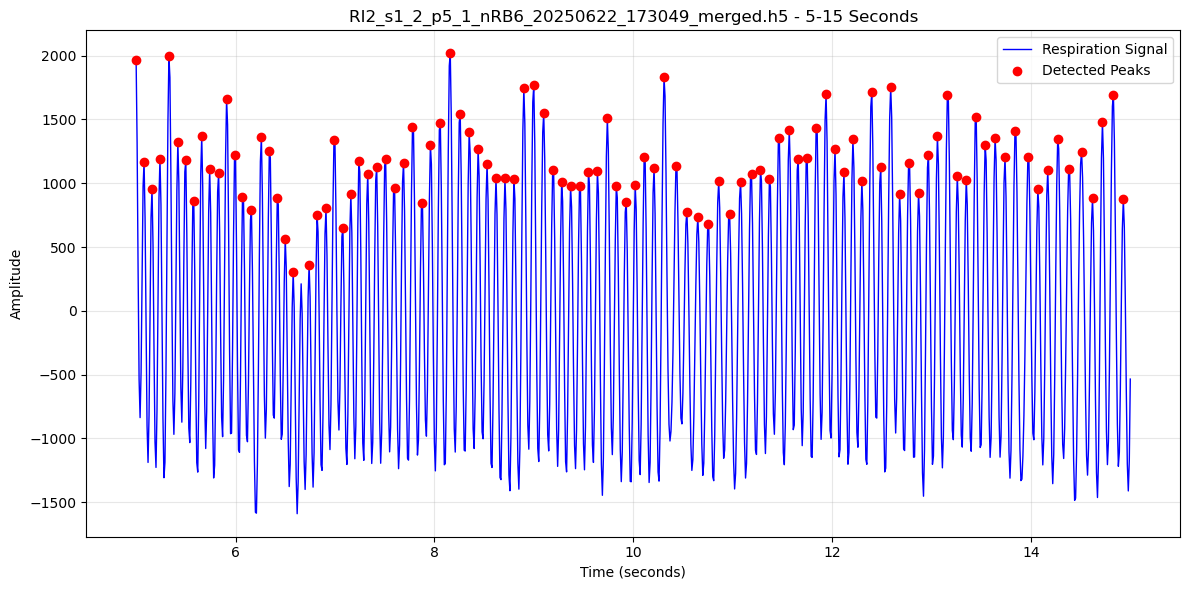

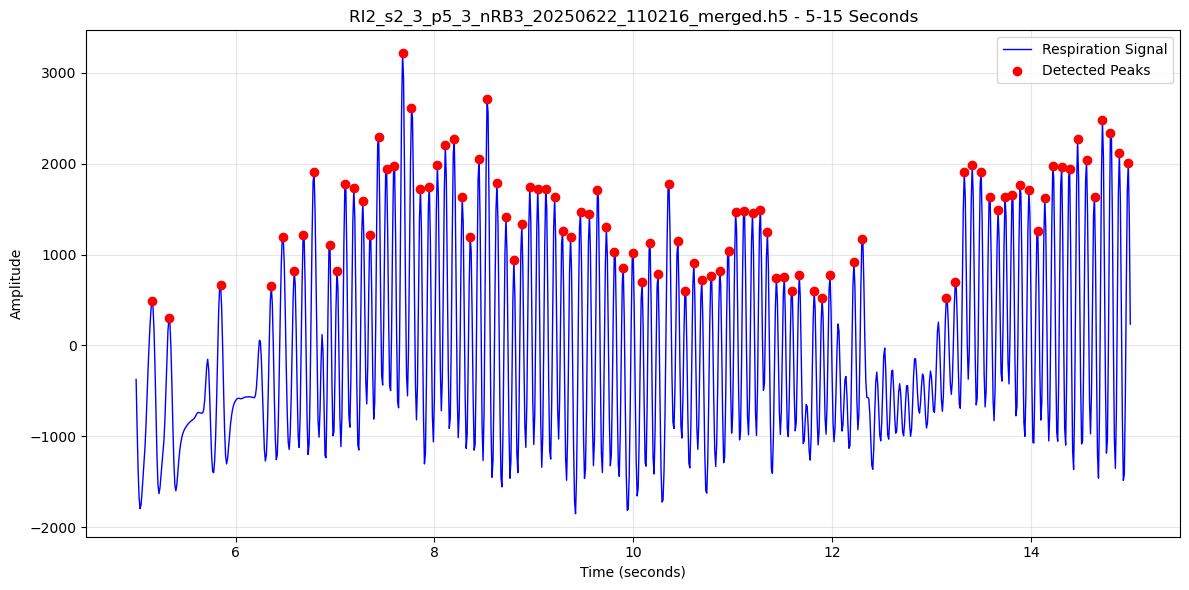

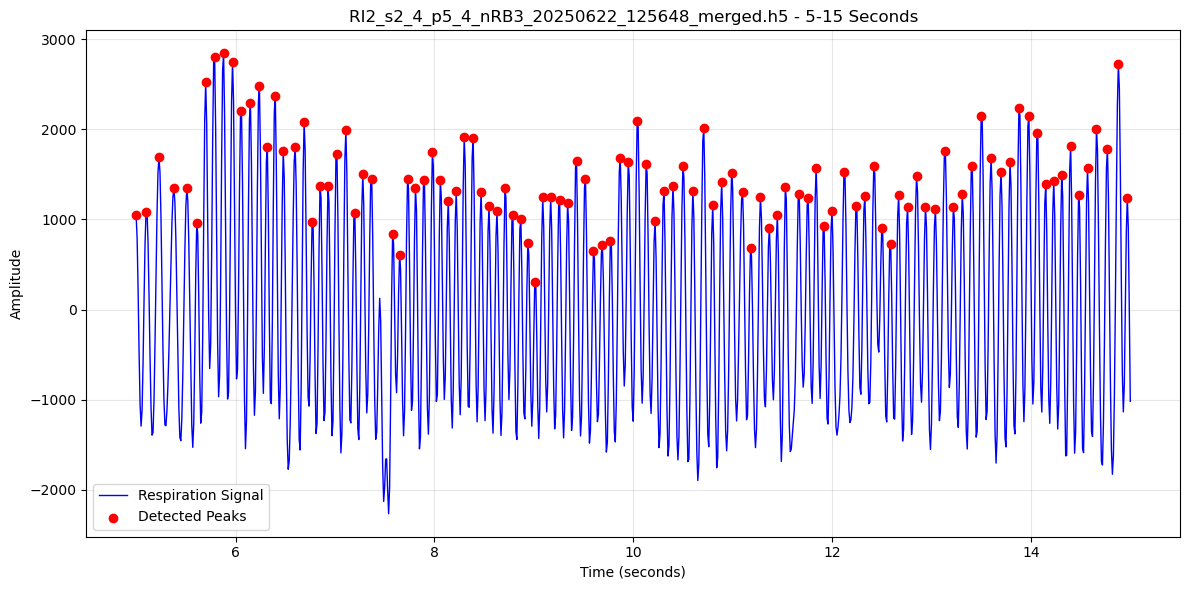

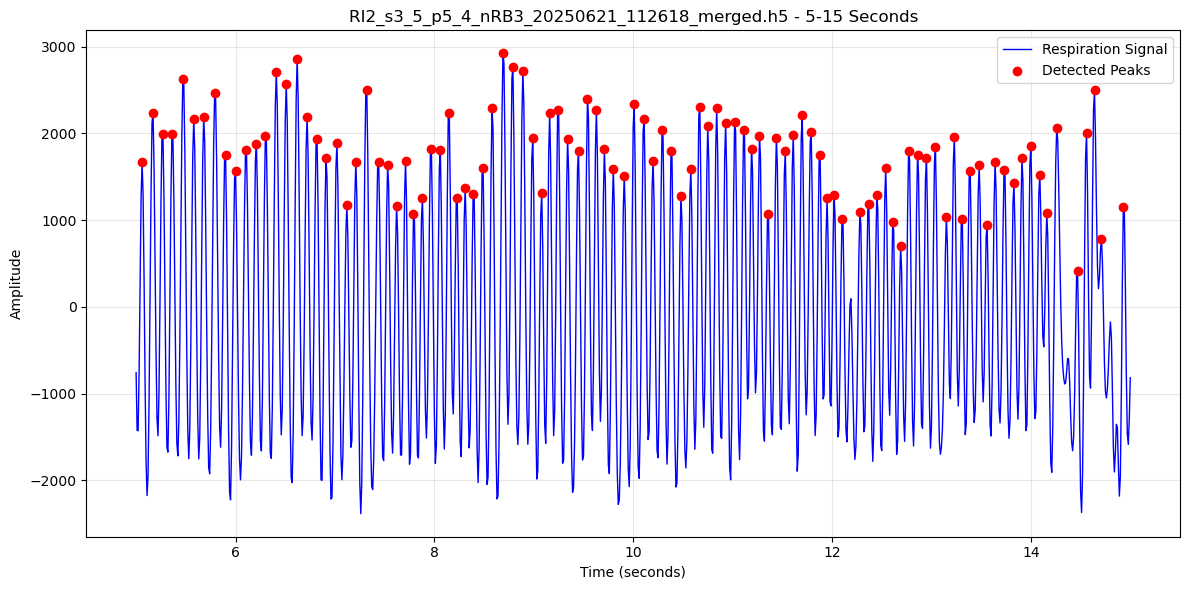

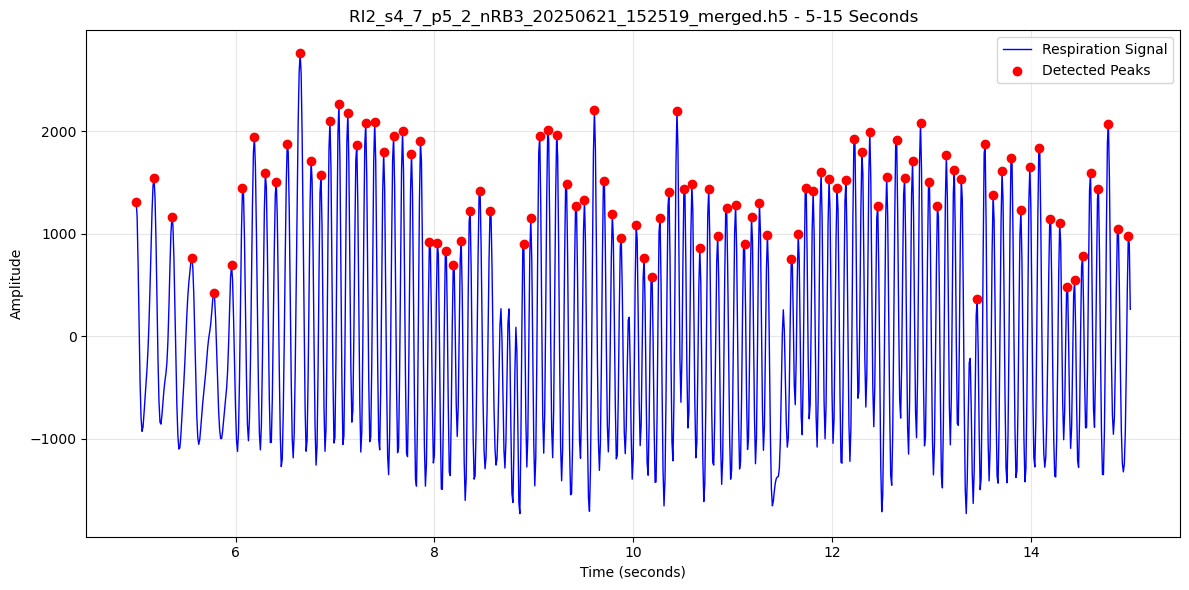

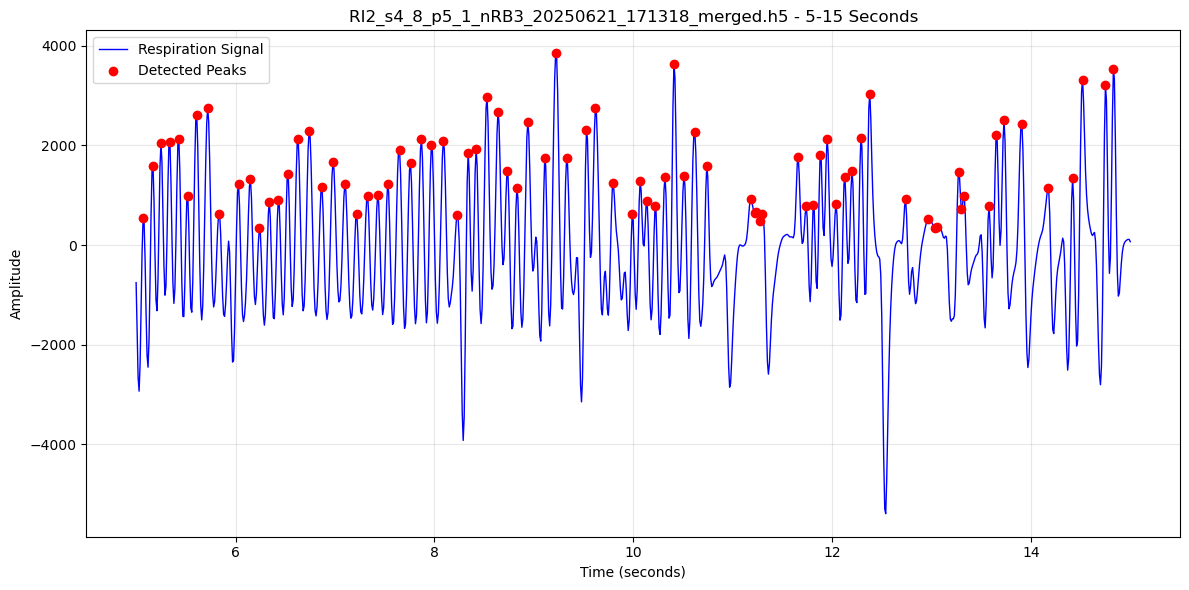

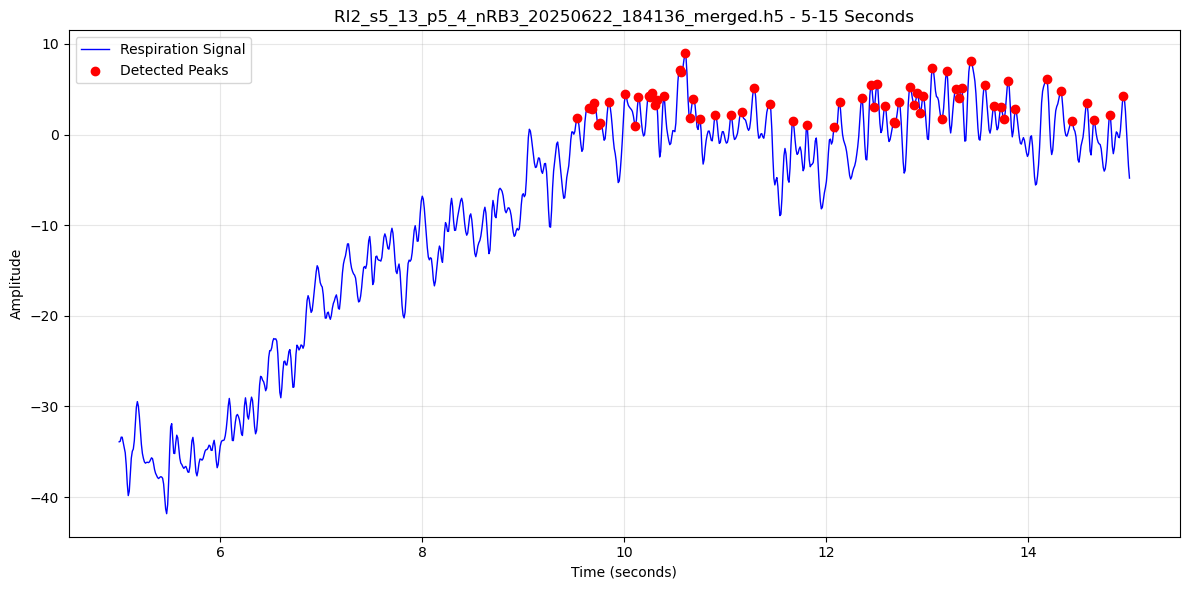

                                          file  original_fs  duration_sec  downsampled_len  duration_downsampled  peak_count  breathing_rate_hz                                                                                                        plot_path                                                               error
 BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5      20000.0        632.01          63201.0                632.01      5342.0               8.45 c:\Users\thoma\Code\ResearchCode\respiratory_pilot\plots\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged_10s_plot.png                                                                 NaN
 BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5      20000.0        610.98          61098.0                610.98      5392.0               8.83 c:\Users\thoma\Code\ResearchCode\respiratory_pilot\plots\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged_10s_plot.png                                                                 NaN
 BLRI_s2_3_p5_3_nRB3_2025

In [16]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk

from rsp.plotting import Rsp_Kit  # Your class for plotting

import sys

if '__file__' in globals():
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    SCRIPT_DIR = os.getcwd()  # Fallback for notebooks and interactive environments

def analyze_and_plot_breathing(h5_file, output_dir=None, target_rate=100):
    
    if output_dir is None:
            output_dir = os.path.join(SCRIPT_DIR, "plots")
    
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Peak detection
    peaks, _ = find_peaks(rsp_cleaned, distance=target_rate // 20)
    breathing_rate_hz = len(peaks) / duration_downsampled

    # Step 5: Plot with Rsp_Kit
    try:
        os.makedirs(output_dir, exist_ok=True)
        rsp_obj = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned))
        fig = rsp_obj.plot(start_time=5, duration=10, show_peaks=True, title=os.path.basename(h5_file))
        plot_path = os.path.join(output_dir, os.path.basename(h5_file).replace(".h5", "_10s_plot.png"))
        plt.savefig(plot_path)
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_downsampled": round(duration_downsampled, 2),
        "peak_count": len(peaks),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
        "plot_path": plot_path
    }

def batch_analyze_directory(directory_path):
    results = []
    output_dir = os.path.join(SCRIPT_DIR, "plots")  # Ensures plots folder is in same directory as script
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path, output_dir=output_dir)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5"
    df_results = batch_analyze_directory(directory)
    print(df_results.to_string(index=False))


C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\rsp\plotting\Rsp_Kit.py:415: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


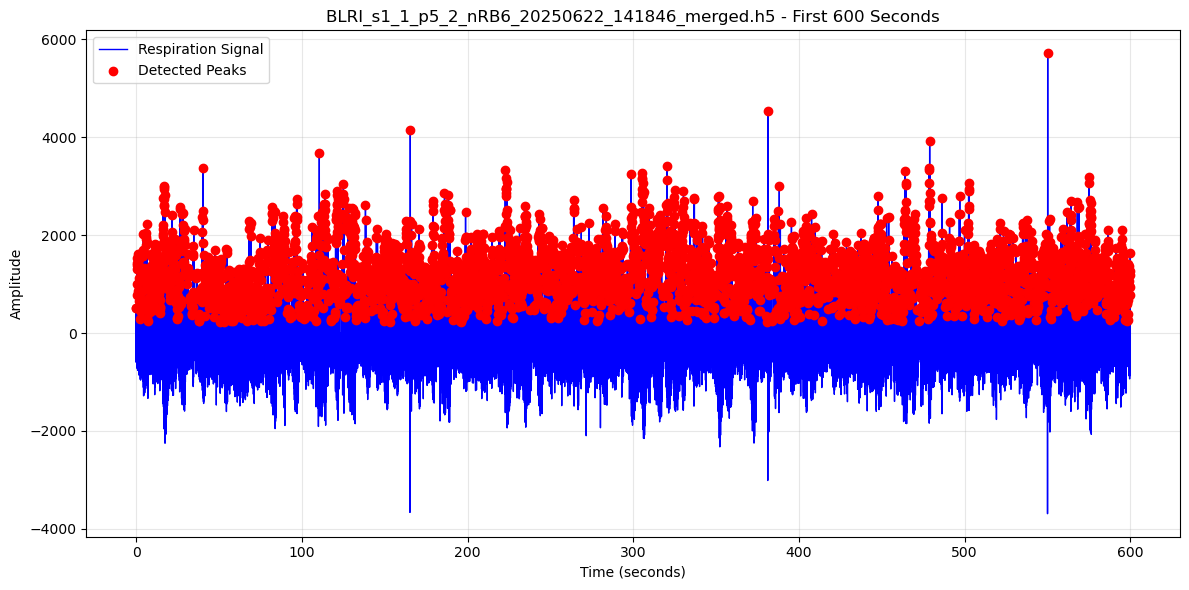

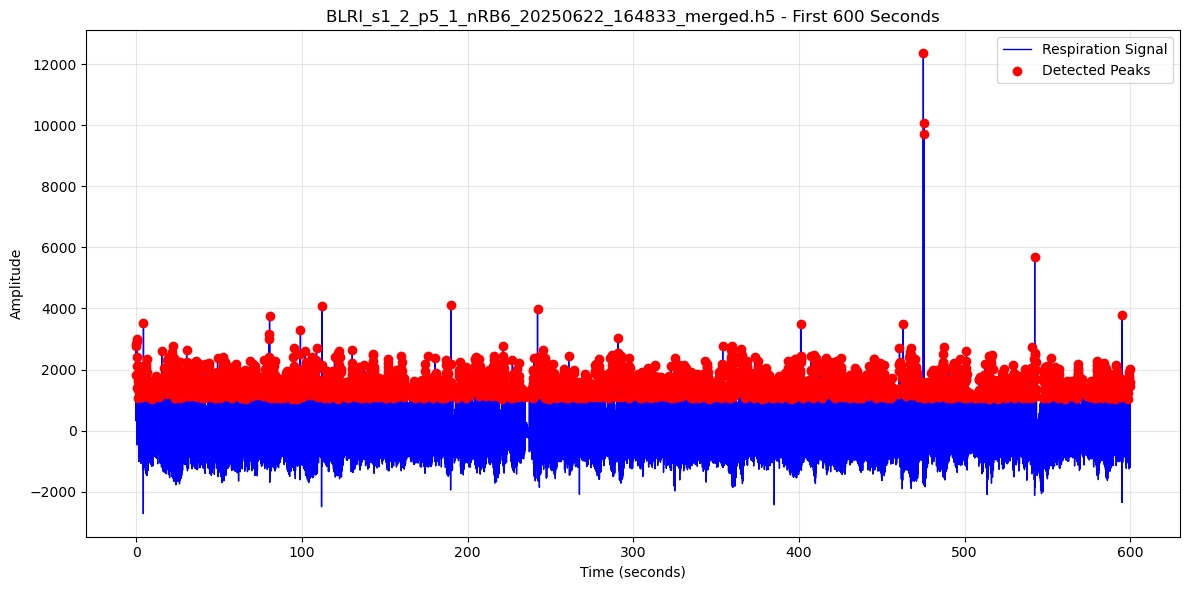

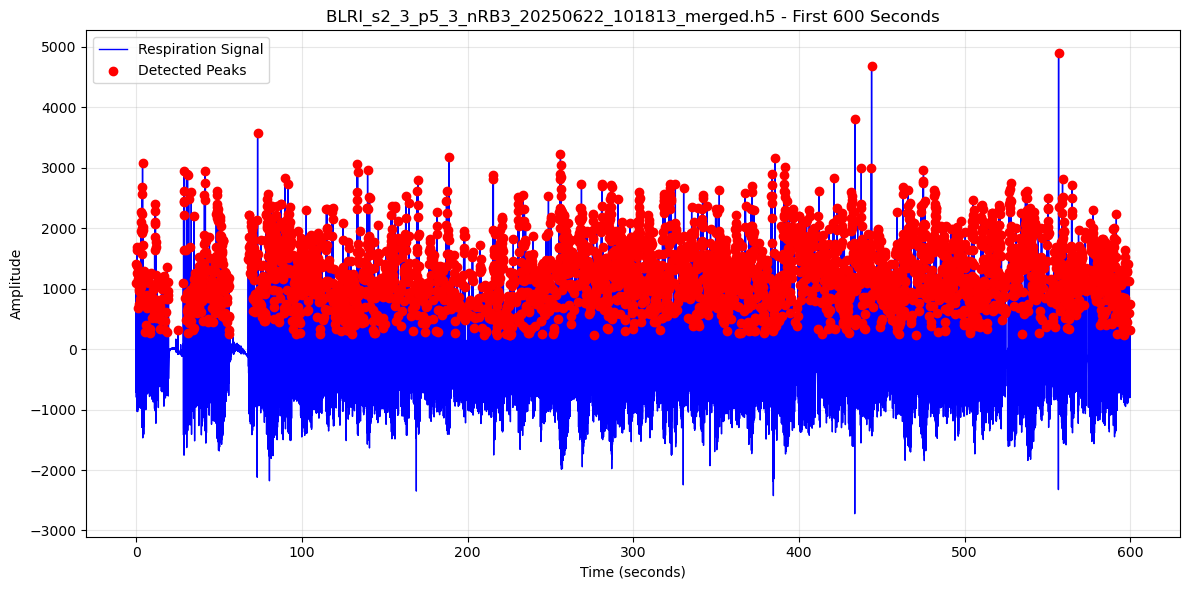

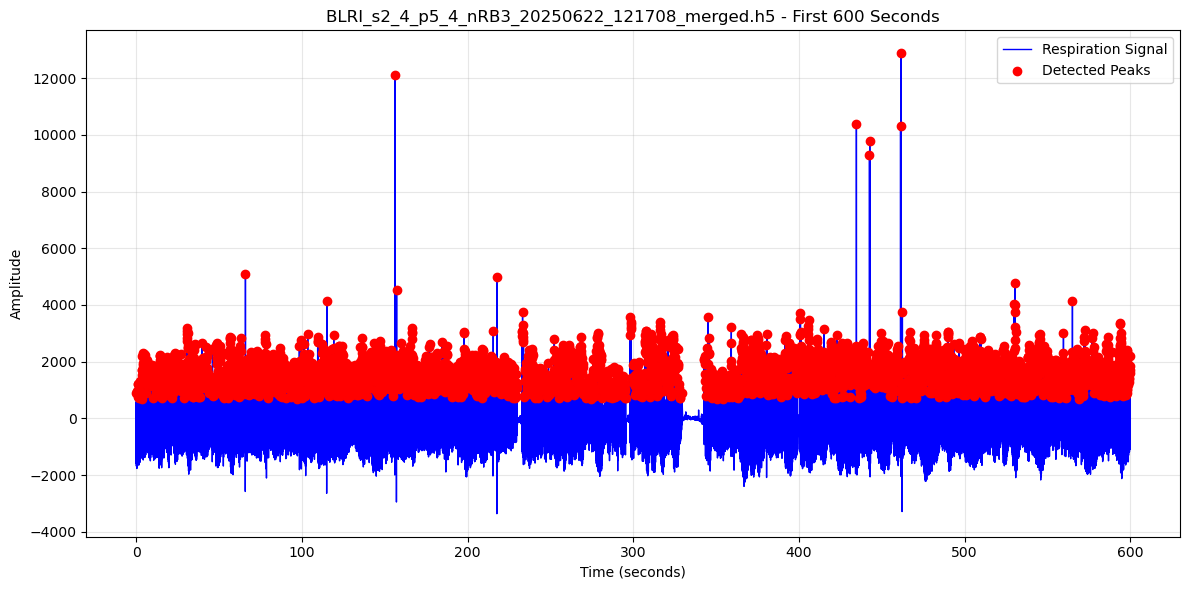

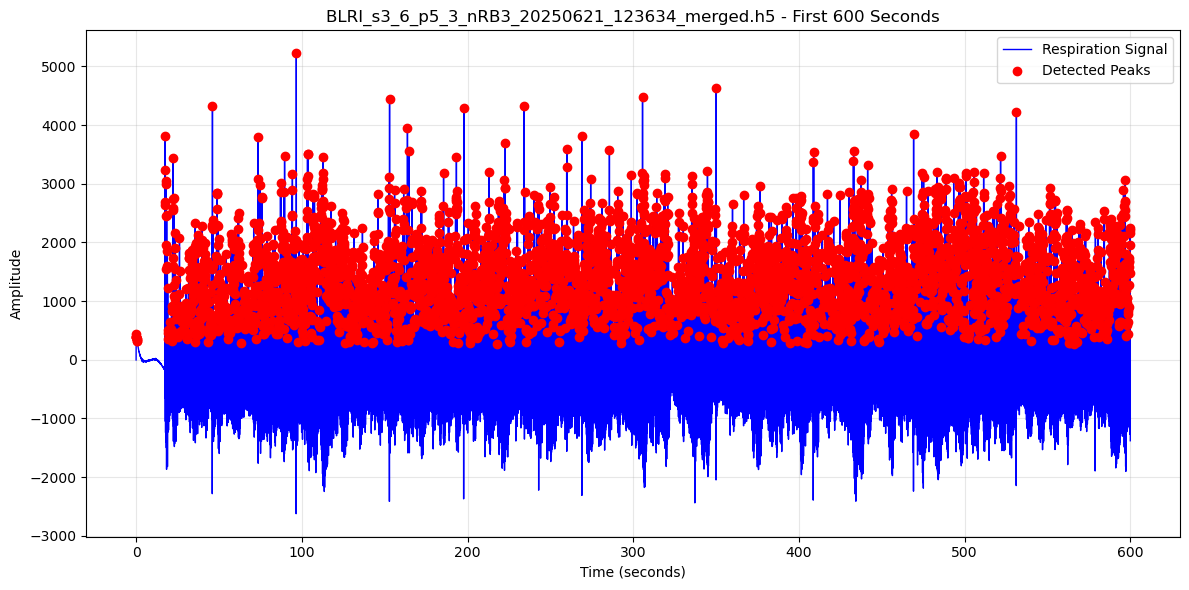

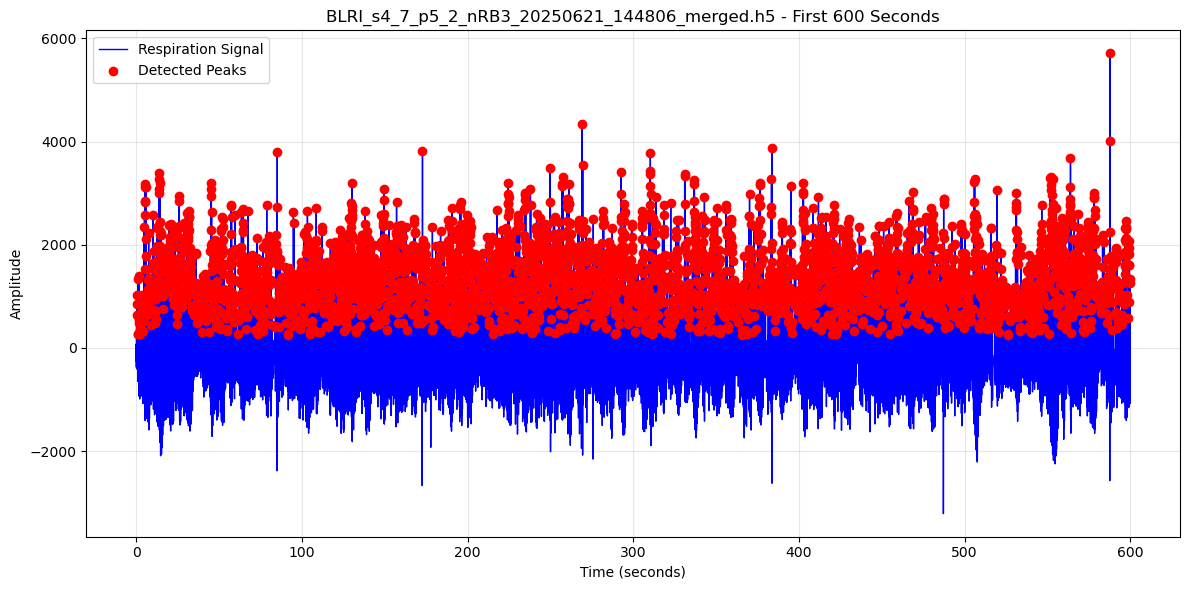

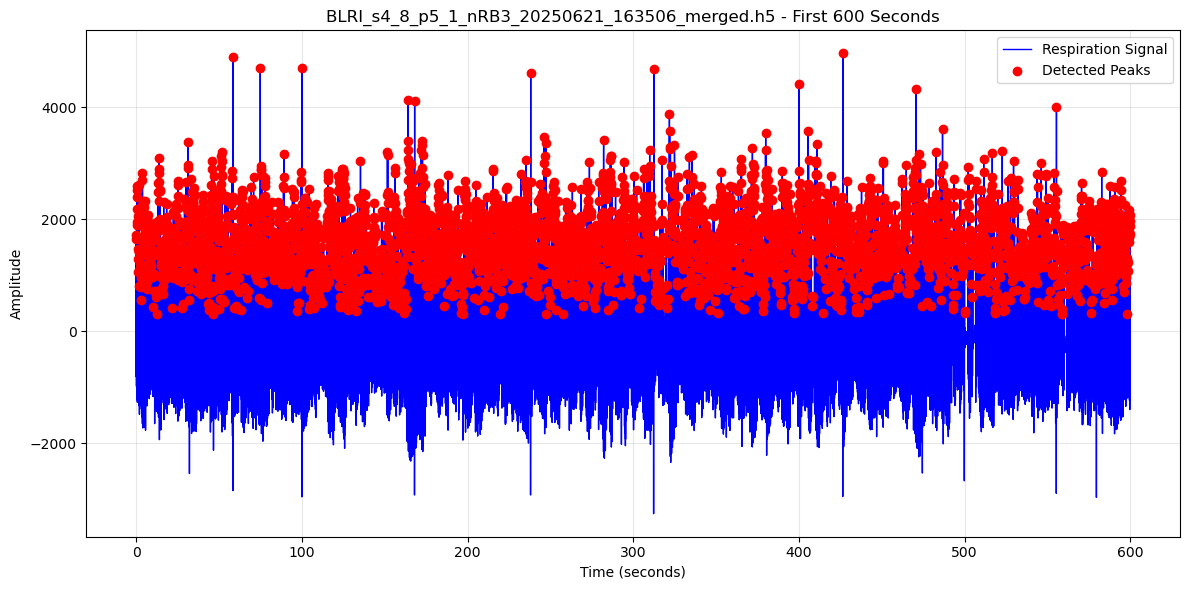

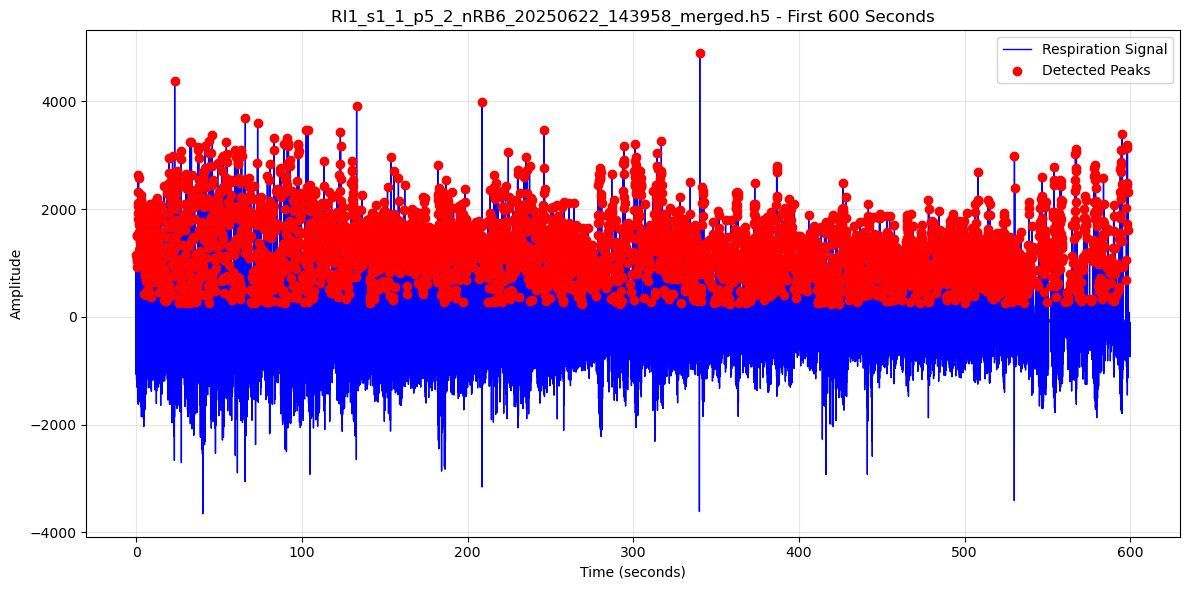

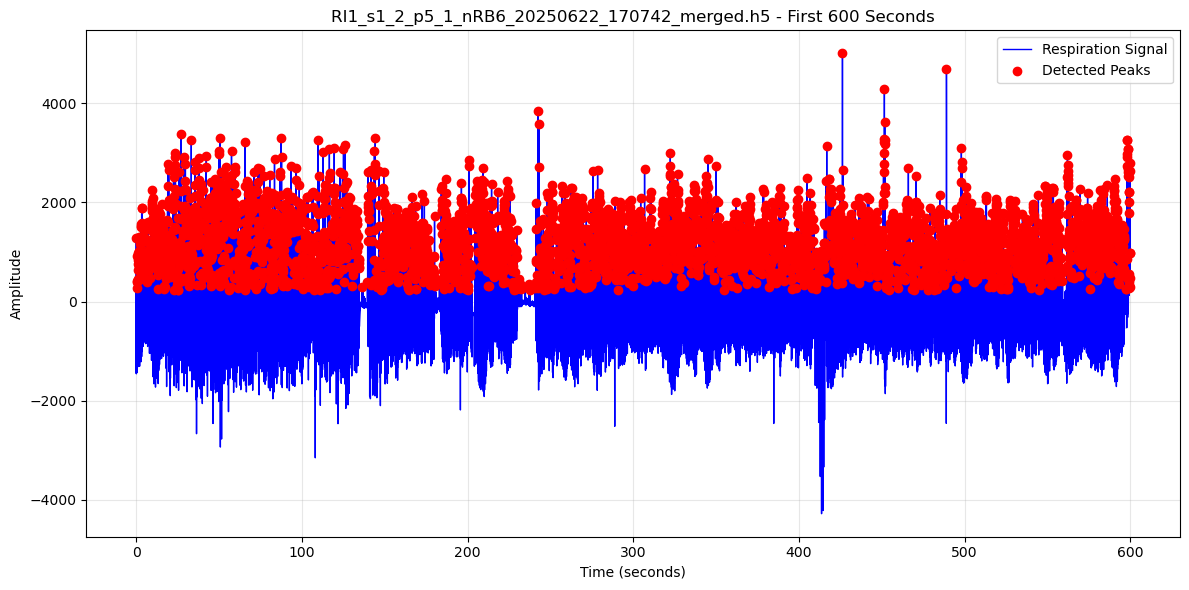

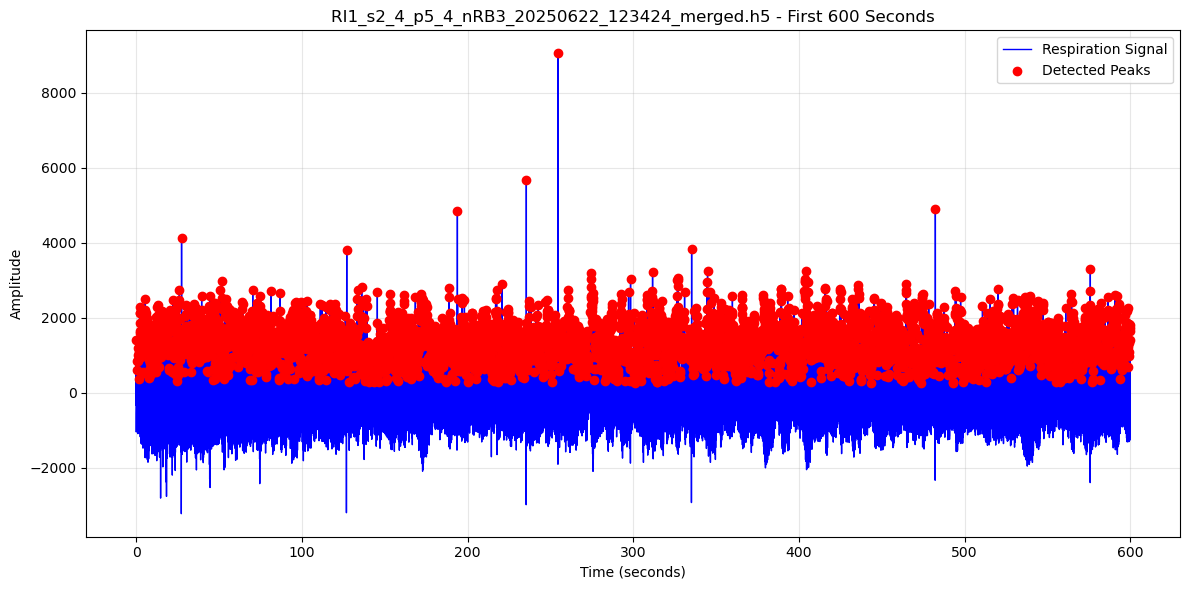

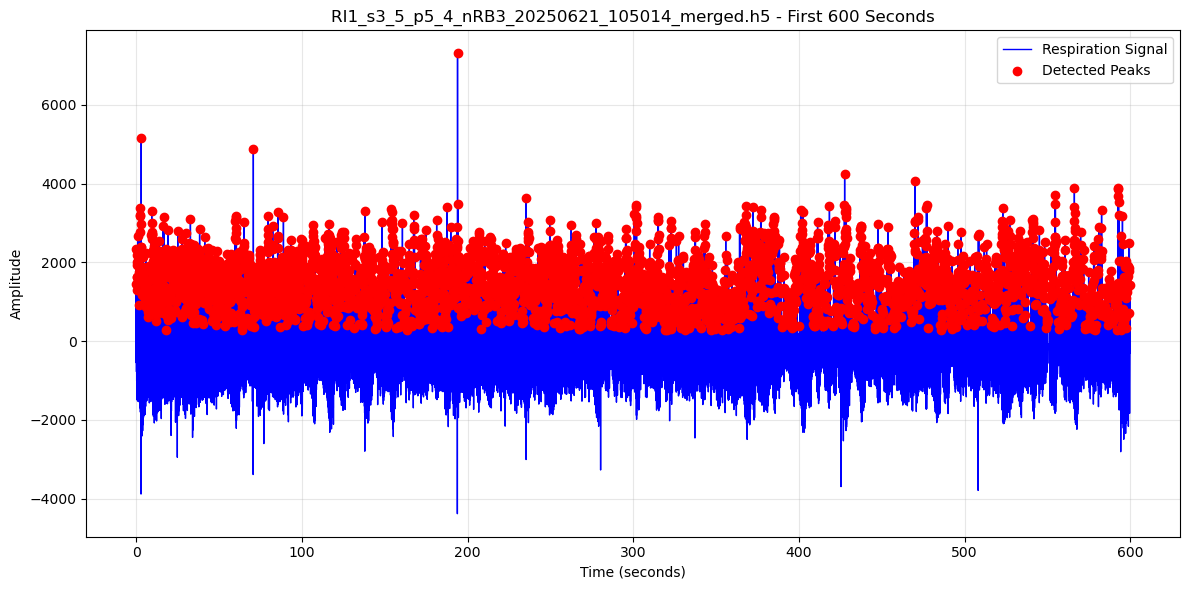

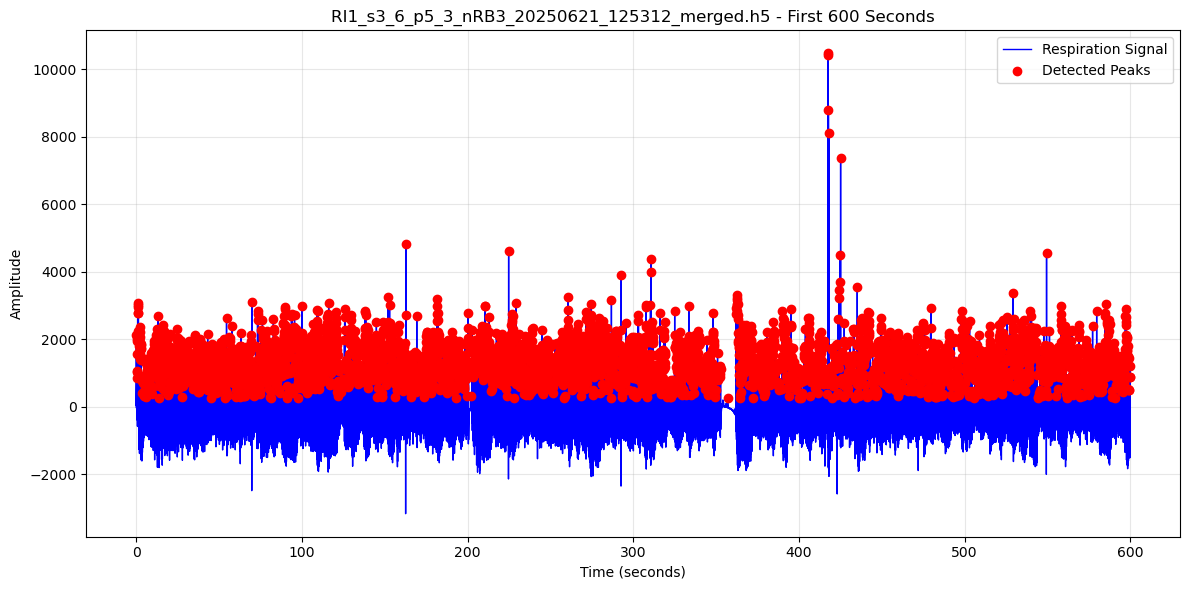

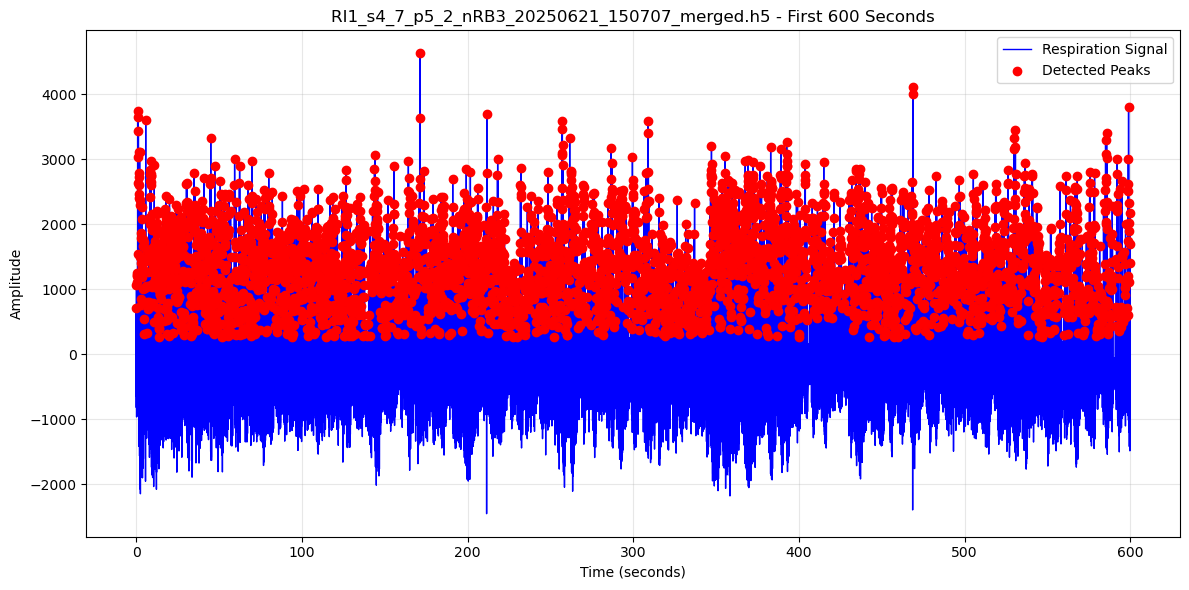

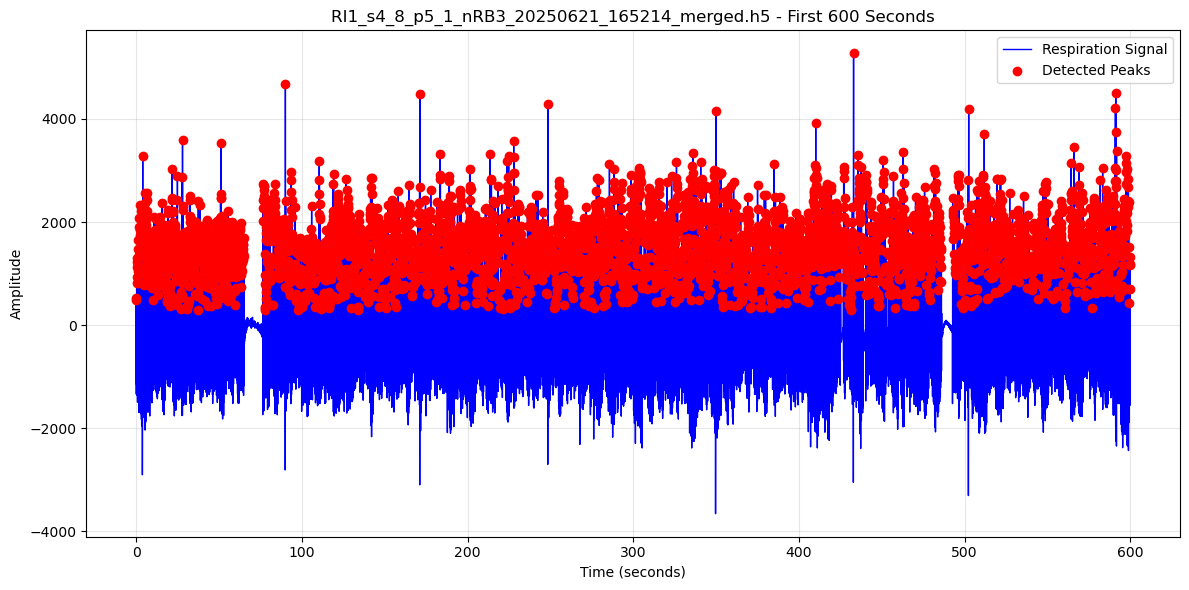

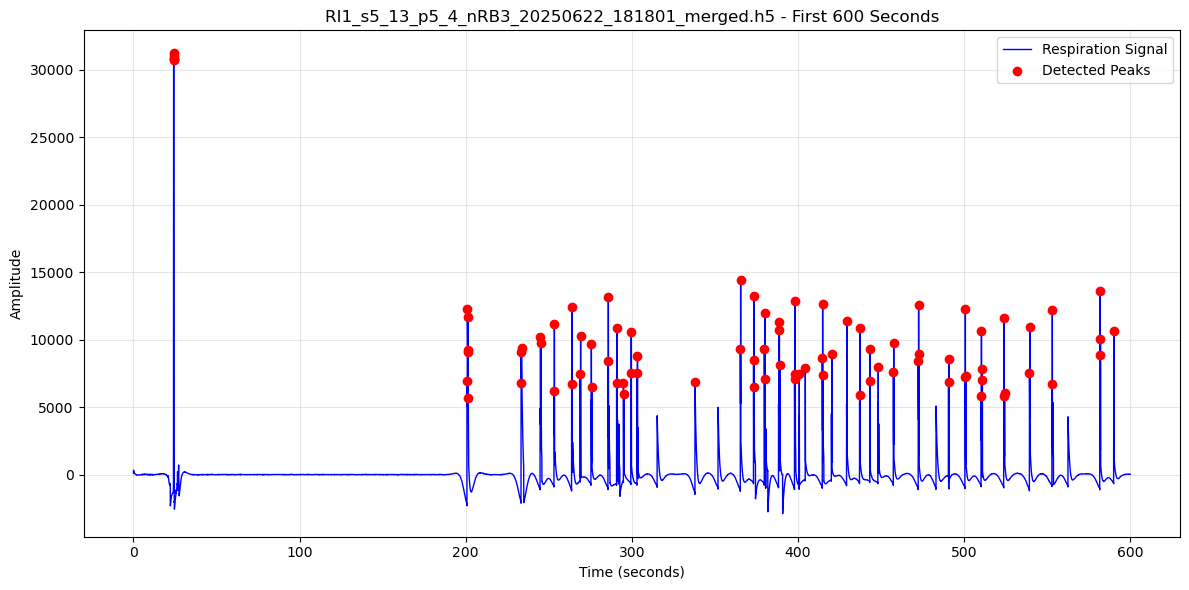

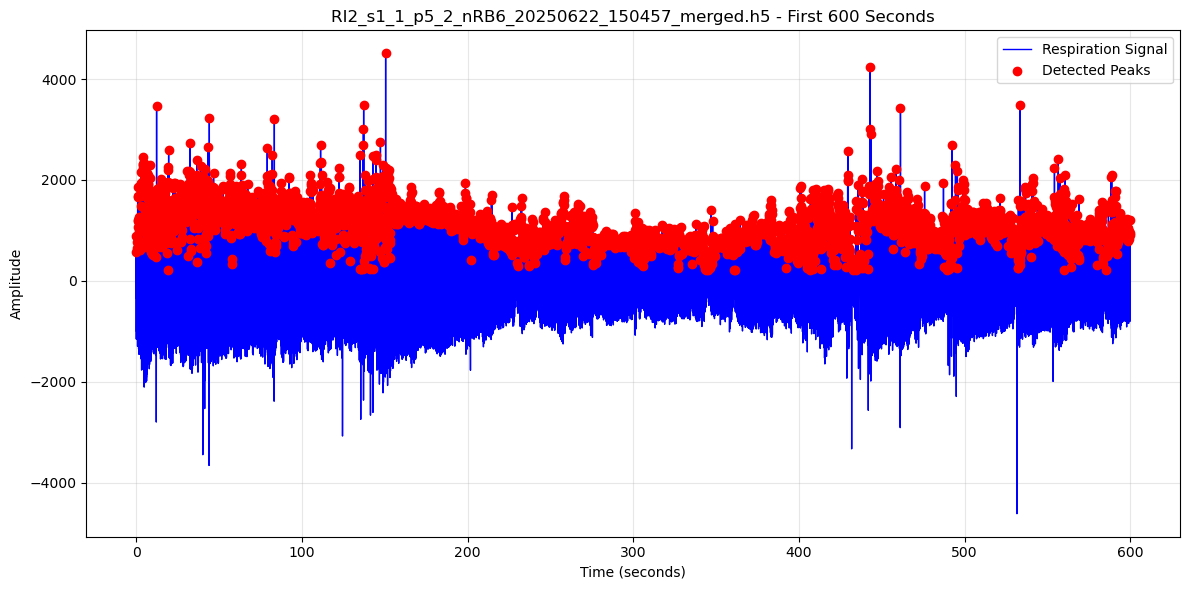

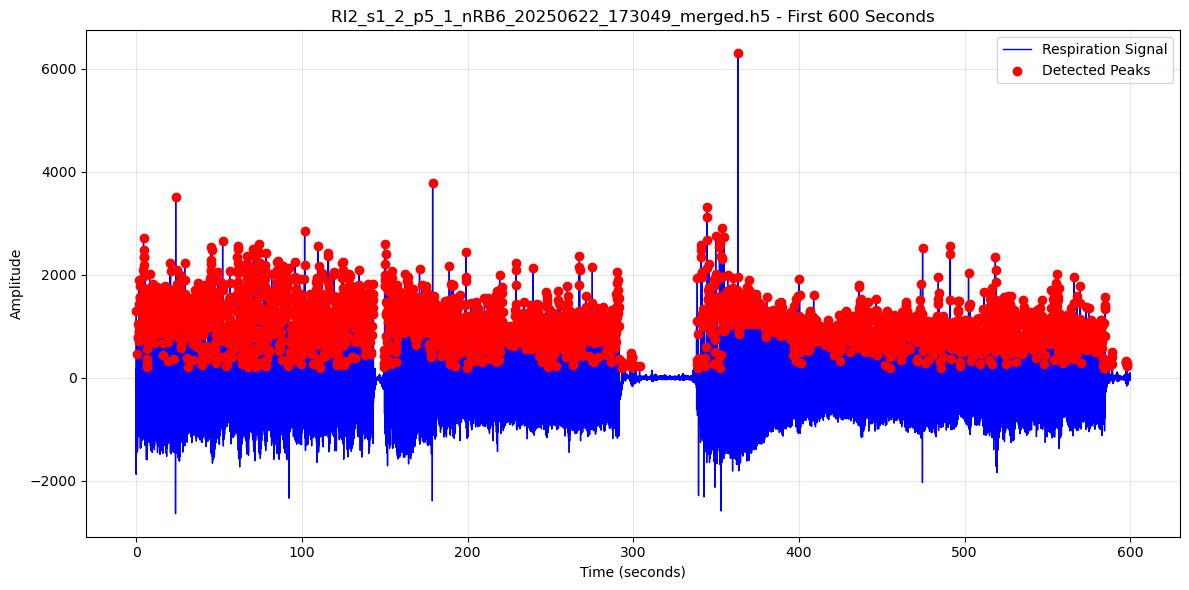

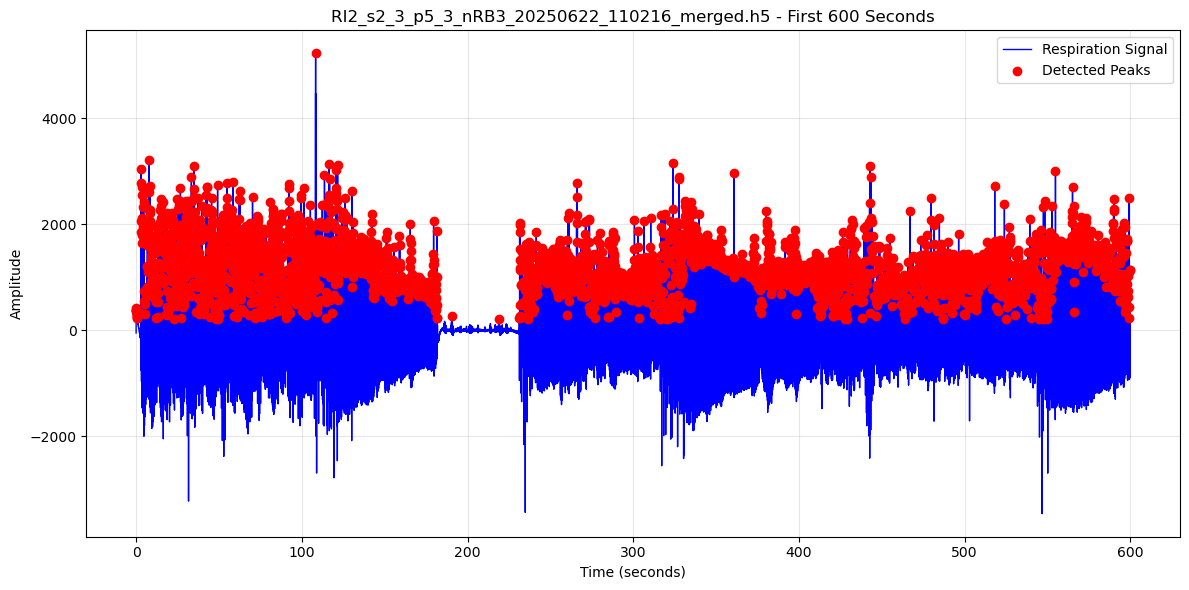

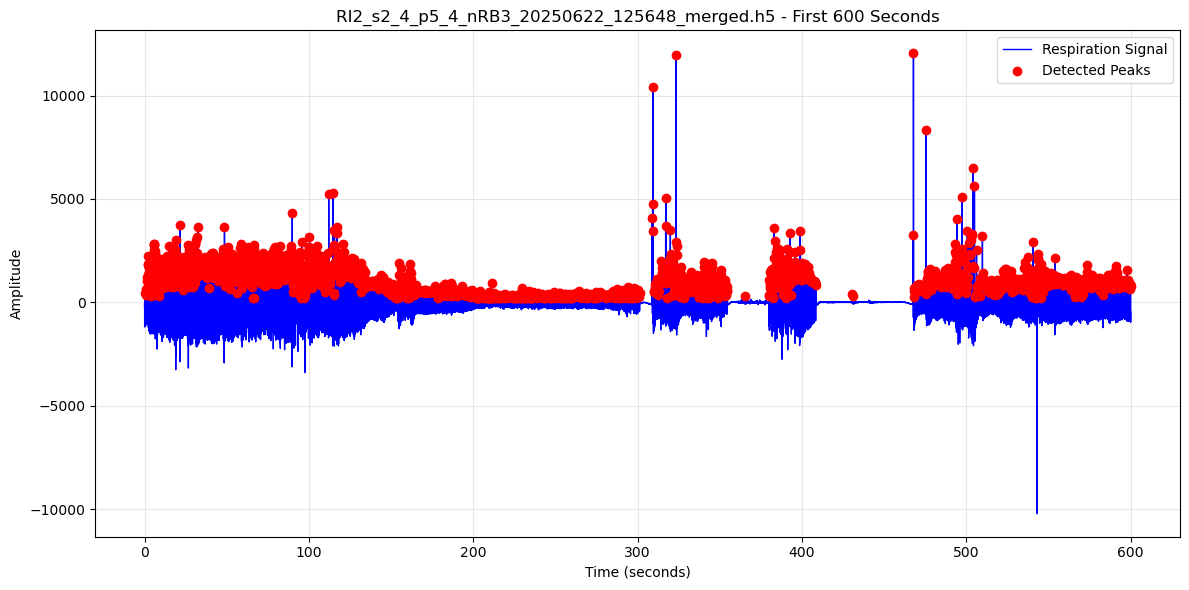

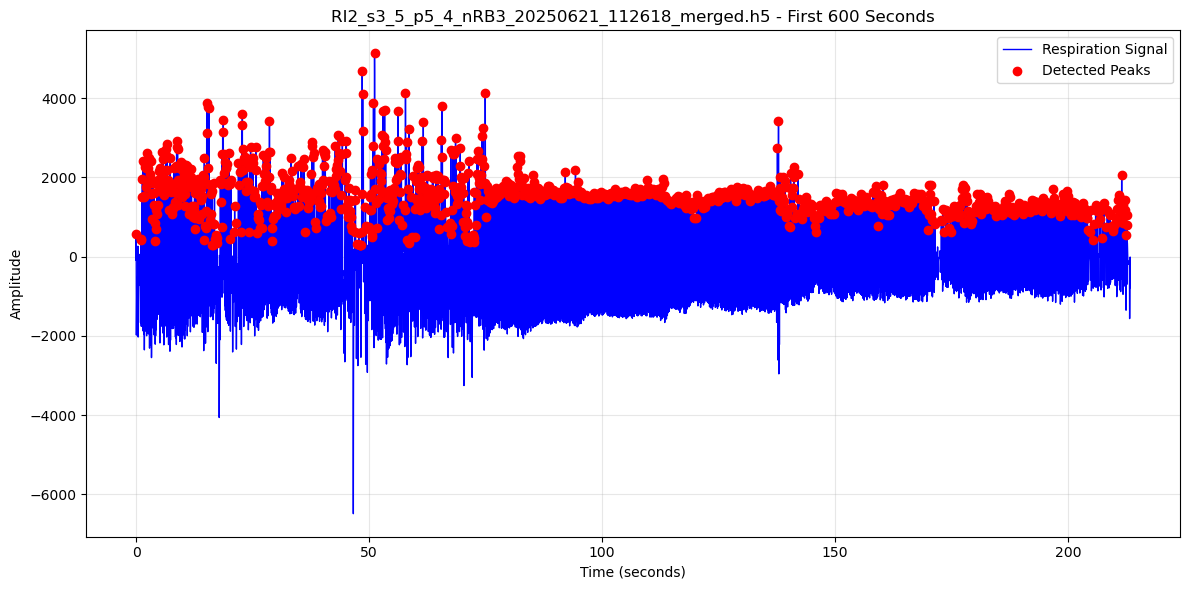

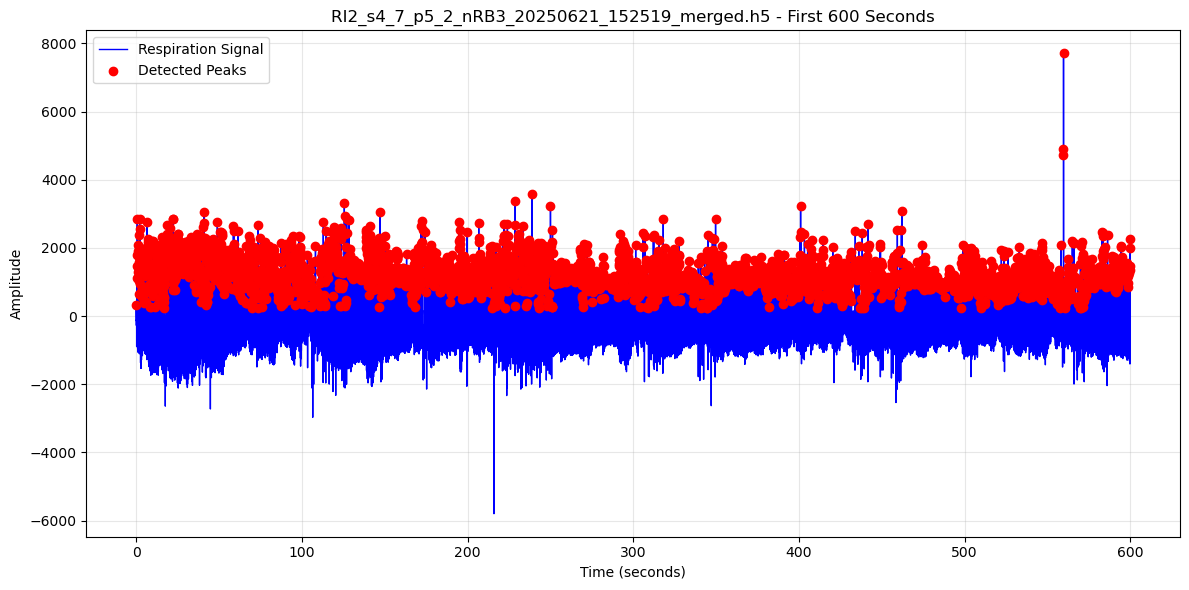

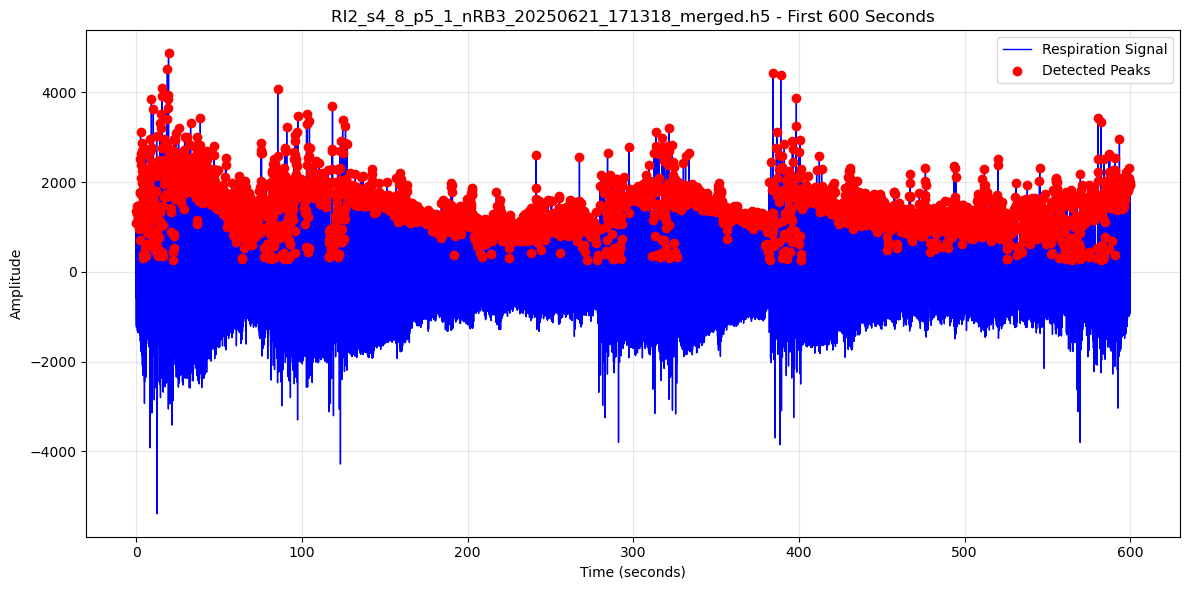

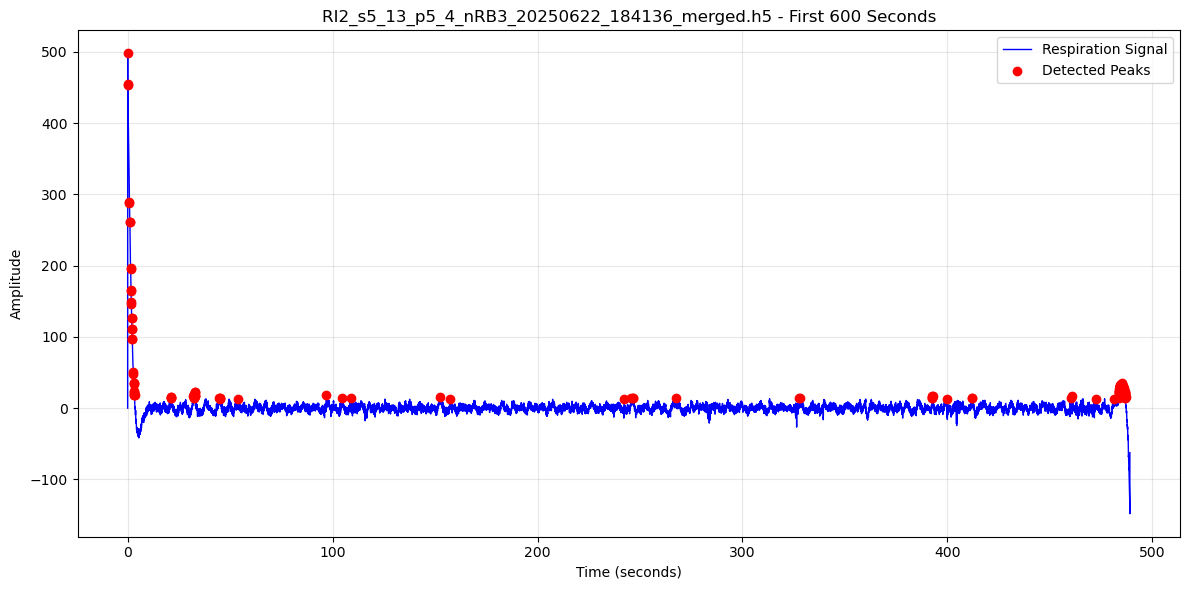

                                          file  original_fs  duration_sec  downsampled_len  duration_downsampled  peak_count  breathing_rate_hz                                                                                                                                            plot_path                                                               error
 BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5      20000.0        632.01          63201.0                632.01      5342.0               8.45 C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\plots\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged_10s_plot.png                                                                 NaN
 BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5      20000.0        610.98          61098.0                610.98      5392.0               8.83 C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\plots\BLRI_s1_2_p5_1_nRB6_20250622_164833_merge

In [12]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk

from rsp.plotting import Rsp_Kit  # Your class for plotting

def analyze_and_plot_breathing(h5_file, output_dir="plots", target_rate=100):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Step 4: Peak detection
    peaks, _ = find_peaks(rsp_cleaned, distance=target_rate // 20)
    breathing_rate_hz = len(peaks) / duration_downsampled

    # Step 5: Plot with Rsp_Kit
    try:
        os.makedirs(output_dir, exist_ok=True)
        rsp_obj = Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned))
        fig = rsp_obj.plot(duration=600, show_peaks=True, title=os.path.basename(h5_file))
        plot_path = os.path.join(output_dir, os.path.basename(h5_file).replace(".h5", "_10s_plot.png"))
        plt.savefig(plot_path)
        plt.close()
    except Exception as plot_err:
        return {"file": os.path.basename(h5_file), "error": f"Plotting failed: {plot_err}"}

    return {
        "file": os.path.basename(h5_file),
        "original_fs": round(fs, 2),
        "duration_sec": round(duration_sec, 2),
        "downsampled_len": len(downsampled_resp),
        "duration_downsampled": round(duration_downsampled, 2),
        "peak_count": len(peaks),
        "breathing_rate_hz": round(breathing_rate_hz, 2),
        "plot_path": plot_path
    }

def batch_analyze_directory(directory_path):
    results = []
    plot_output_dir = os.path.join(directory_path, "plots")
    for file in os.listdir(directory_path):
        if file.endswith(".h5"):
            full_path = os.path.join(directory_path, file)
            result = analyze_and_plot_breathing(full_path, output_dir=plot_output_dir)
            results.append(result)
    return pd.DataFrame(results)

# 👉 SET YOUR DIRECTORY PATH HERE
if __name__ == "__main__":
    directory = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5"
    df_results = batch_analyze_directory(directory)
    print(df_results.to_string(index=False))
